# 📈 LAB TOOLS &mdash; Ajuste de Curvas

---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta determina **parâmetros e informações estatísticas** de ajustes de curvas a dados experimentais.

**Modelos disponíveis:**

1. Linear: $$y = Ax + B$$
2. Polinômio de grau $n$: $$y=a_0+a_1x+a_2x^2+\cdots+a_nx^n$$
3. Exponencial: $$y=Ae^{-\gamma x}+B$$
4. Logaritmo: $$y=A\ln(x)+B$$
5. Seno: $$y=A\sin(\omega x +\phi)+B$$
6. Cosseno: $$y=A\cos(\omega x +\phi)+B$$
7. Potência: $$y=Ax^\gamma +B$$
8. Logístico: $$y=\frac{L-B}{1+e^{-k(x-x_0)}}+B$$
9. Gaussiano: $$y=Ae^{-(x-\mu)^2/2\sigma^2}+B$$
10. Lorentziano: $$y=\frac{A\gamma^2}{(x-x_0)^2 +\gamma^2} + B$$

Os dados podem contar incertezas tanto na variável independente quanto na variável dependente. O método de ajuste usado é o **método dos mínimos quadrados não linear com ponderação** (NWLS - nonlinear weighted least squares) disponível na biblioteca SciPy.

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo.  

---
### Formatos de arquivo aceitos

| Formato | Extensão |
|---|---|
| XLSX - Planilha do Excel | `.xlsx` |
| CSV - Valores separados por vírgula | `.csv` `.txt` |


Nomes de grandeza com sinais diacríticos como **acentos, cedilha ou til** (`posição`, `força`, `ângulo` ou `pressão`, por exemplo) são aceitos. Há campos na interface gráfica para indicar os rótulos (nomes ou símbolos) das grandezas e suas unidades.  

No formato `XLSX`, cada grandeza deve ocupar uma coluna da planilha e os valores numéricos podem usar `.` ou `,` como separador decimal.

Para indicar os rótulos (nomes ou símbolos das grandezas) e as unidades das grandezas medidas, use as palavras-chave `#rótulos:` e `#unidades:` seguidas de valores separados por `,` ou por `;`.

As informações sobre rótulos e unidades devem estar obrigatoriamente nas células `A1` e `A2`, respectivamente, antes das linhas que contêm os valores numéricos dos dados:

|   |    A                         | B       |
|:--|:------                       |:--------|
| 1 | #rótulos: Tempo, Posição     |         |     
| 2 | #unidades: s, m              |         |    
| 3 | 10.0                         | 15.2    |     

No formato `CSV`, os valores devem ser separados por `,` ou por `;`. Os valores numéricos podem usar `.` ou `,` como separador decimal. Se usar `,` como separador decimal, use `;` como separador de valores, para evitar ambiguidade.

Os rótulos e as unidades das grandezas medidas podem ser informados em linhas de comentários (iniciadas com `#`), antes das linhas que contêm os valores numéricos dos dados.

Para indicar rótulos e unidades, use as palavras-chave `#rótulos:` e `#unidades:`no início das linhas, seguidas de valores separados por `,` ou por `;`:

```
 #rótulos: Tempo, Posição
 #unidades: s, m
 10.0, 15.2
 ...
```
Se estas linhas estiverem ausentes, rótulos e unidades poderão ser
preenchidas manualmente em campos presentes na interface gráfica.

---
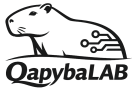

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **LAB TOOLS &mdash; Ajuste de Curvas**
# ── Célula 1: ajuste de curvas ───────────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo modelos, métodos,
# pacotes a serem usados e linhas gerais da inteface gráfica, mas a maior parte
# do código, especialmente as funções para leitura de arquivos e para a
# interface gráfica, foi escrita usando o modelo Claude Sonnet 4.6.
# O código gerado foi inspecionado e sofreu diversas alterações e correções
# realizadas pelo licenciante e pelo modelo Gemini 3.5-flash.

import math, io, re, base64, unicodedata, warnings
import numpy as np
from scipy.optimize import curve_fit
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as w
from IPython.display import display, HTML, clear_output

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ══════════════════════════════════════════════════════════════════
#  NORMALIZAÇÃO DE NOMES
#  remove acentos e outros diacríticos para uso em nomes de arquivo
# ══════════════════════════════════════════════════════════════════
def nome_para_arquivo(nome):
    """Converte nome com acentos/cedilha para versão segura para nomes
    de arquivo (ex: 'posição' → 'posicao')."""
    nfd = unicodedata.normalize("NFD", nome)
    return "".join(c for c in nfd
                   if unicodedata.category(c) != "Mn"
                   ).replace(" ", "_")

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte LAB/NEWTON TOOLS:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (violeta fixo)
#    .res-t → tabela de dados (cabeçalho azul-marinho fixo)
#  Acento desta ferramenta: azul #3b5bdb
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#3b5bdb;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.res-t{border-collapse:collapse;font-size:.83rem;width:40%;margin:6px 0;}
.res-t th{background:#1a1a2e;color:#fff;padding:5px 10px;text-align:left;}
.res-t td{padding:4px 10px;text-align:left;border-bottom:1px solid #eee;
  font-family:monospace;}
.res-t tr:nth-child(odd) td{text-align:left}
.res-t tr:nth-child(even) td{background:#eafcff;text-align:left}
.cov-t{border-collapse:collapse;font-family:monospace;font-size:.83rem;margin:5px 0;}
.cov-t th{background:#3b5bdb;color:#fff;padding:4px 11px;text-align:left;}
.cov-t td{padding:3px 11px;text-align:left;border:1px solid #dde;}
.cov-t tr:nth-child(odd) td{text-align:left}
.cov-t tr:nth-child(even) td{background:#f0f4ff;text-align:left}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  MODELOS
# ══════════════════════════════════════════════════════════════════
def modelo_exp(x,A,gamma,B):    return A*np.exp(-gamma*x) + B
def modelo_log(x,A,B):      return A*np.log(x) + B
def modelo_sin(x,A,omega,phi,B):  return A*np.sin(omega*x+phi) + B
def modelo_cos(x,A,omega,phi,B):  return A*np.cos(omega*x+phi) + B
def modelo_pot(x,A,gamma,B):    return A*np.power(x,gamma) + B
def modelo_logistico(x,x0,L,k,B): return (L-B)/(1+np.exp(-k*(x-x0))) + B
def modelo_gauss(x,mu,sigma,A,B): return A*np.exp(-0.5*((x-mu)/sigma)**2) + B
def modelo_lorentz(x,x0,A,gamma,B): return A*gamma**2/((x-x0)**2+gamma**2) + B

MODELOS_FUNC = {"Exponencial":modelo_exp,"Logaritmo":modelo_log,
                "Seno":modelo_sin,"Cosseno":modelo_cos,
                "Potência":modelo_pot,"Logístico":modelo_logistico,
                "Gaussiana":modelo_gauss,"Lorentziana":modelo_lorentz}

# Limites (bounds) para parâmetros que precisam ser positivos
# (evita σ ou γ negativos, que são matematicamente equivalentes
# mas confundem a interpretação física do resultado).
# Ainda é necessário encontrar uma maneira de garantir que a amplitude A
# dos modelos Seno e Cosseno seja negativa sem comprometer a qualidade do ajuste.
BOUNDS = {
    "Gaussiana":   ([-np.inf, 1e-12, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
    "Lorentziana": ([-np.inf, -np.inf, 1e-12, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
}

# Expressões e parâmetros para cada modelo
EXPR = {
    "Linear":     "A·x + B",
    "Polinômio":  "a₀+a₁·x+a₂·x²+…",
    "Exponencial":"A·exp(−γ·x)+B",
    "Logaritmo":  "A·ln(x)+B",
    "Seno":       "A·sin(ω·x+φ)+B",
    "Cosseno":    "A·cos(ω·x+φ)+B",
    "Potência":   "A·x^γ + B",
    "Logístico":  "(L−B)/(1+exp(−k·(x−x₀)))+B",
    "Gaussiana":  "A·exp(−½·(x−μ)²/σ²)+B",
    "Lorentziana":"A·γ²/((x−x₀)²+γ²)+B",
}
PARAMS = {
    "Exponencial":["A","γ","B"],
    "Logaritmo":  ["A","B"],
    "Seno":       ["A","ω","φ","B"],
    "Cosseno":    ["A","ω","φ","B"],
    "Potência":   ["A","γ","B"],
    "Logístico":  ["x0","L","k","B"],
    "Gaussiana":  ["μ","σ","A","B"],
    "Lorentziana":["x0","A","γ","B"],
}

# ══════════════════════════════════════════════════════════════════
#  METADADOS E MATEMÁTICA
# ══════════════════════════════════════════════════════════════════
def fmt_sig(v,sig=4):
    v=float(v)
    if not math.isfinite(v) or v==0: return str(v)
    d=int(math.floor(math.log10(abs(v))))-(sig-1)
    return (f"{round(v,-d):.{max(0,-d)}f}" if d>=0 else f"{v:.{-d}f}")

def eh_numero(s):
    """Verifica se uma string representa um número (aceita ',' decimal)."""
    try:
        float(str(s).replace(',', '.'))
        return True
    except (ValueError, AttributeError):
        return False

def parse_rotulo_unidade(texto):
    """Extrai rótulo e unidade de uma string de cabeçalho, ex.:
    'Posição (m)' -> ('Posição','m')   |   'tempo' -> ('tempo','')
    Aceita acentos, cedilha e outros diacríticos normalmente (str unicode)."""
    texto=str(texto).strip()
    m=re.match(r'^(.*?)\s*\(([^()]*)\)\s*$', texto)
    if m and m.group(1).strip():
        return m.group(1).strip(), m.group(2).strip()
    return texto, ''

def extrair_metadados(linha_str):
    """Reconhece linhas de metadados do tipo:
        # unidades: m, N
    (aceita 'unidades'/'unidade'/'units'/'unit', com valores separados
    por vírgula ou tabulação).
    Retorna (chave, [valores]) ou (None, None) se a linha não for
    reconhecida como metadado de unidades.

    Os rótulos (nomes) das grandezas NÃO são lidos de comentários —
    seguem a mesma convenção usada em "Tratamento de Dados
    Experimentais": são lidos diretamente da primeira linha válida
    (cabeçalho) do arquivo, ex.: 'Posição (m)' ou 'tempo'."""
    s=str(linha_str).strip()
    if not s.startswith('#'): return None,None
    s=s.lstrip('#').strip()
    if ':' not in s: return None,None
    chave,resto=s.split(':',1)
    chave=chave.strip().lower()
    valores=[v.strip() for v in re.split(r'[,\t]',resto) if v.strip()!='']
    if not valores: return None,None
    if chave in ('unidades','unidade','units','unit'):
        return 'unidades',valores
    return None,None

def p0_auto(modelo,xs,ys):
    xr=np.ptp(xs) or 1.; yr=np.ptp(ys) or 1.; ym=float(np.mean(ys))
    if modelo=="Exponencial": return [yr,1./xr,float(np.min(ys))]
    if modelo=="Logaritmo":   return [1.,ym]
    if modelo in ("Seno","Cosseno"): return [yr/2,2*np.pi/xr,0.,ym]
    if modelo=="Potência":
        c0=float(np.min(ys))
        i_min,i_max=int(np.argmin(xs)),int(np.argmax(xs))
        a0=float(ys[i_max]-ys[i_min]) or 1.
        return [a0,1.,c0]
    if modelo=="Logístico":
        order=np.argsort(xs); y_o=ys[order]
        Lmax=float(np.max(ys)); Lmin=float(np.min(ys))
        k0=(4./xr) if y_o[-1]>=y_o[0] else (-4./xr)
        return [float(np.median(xs)),Lmax,k0,Lmin]
    if modelo in ("Gaussiana","Lorentziana"):
        # estima o pico como o ponto mais afastado da mediana de y
        # (funciona tanto para picos positivos quanto para "vales")
        base0=float(np.median(ys))
        idx=int(np.argmax(np.abs(ys-base0)))
        pos0=float(xs[idx]); amp0=float(ys[idx]-base0)
        larg0=xr/4. or 1.
        if modelo=="Gaussiana": return [pos0,larg0,amp0,base0]   # μ, σ, A, b
        return [pos0,amp0,larg0,base0]                            # x0, A, γ, b

def ajustar(xs,ys,sys_,sxs,modelo,grau,p0_manual,tem_sx,tem_sy):
    # Linear e Polinômio usam a mesma rota: regressão polinomial analítica.
    # Para Linear, grau_efetivo=1 e os coeficientes são renomeados [B, A].
    if modelo in ("Polinômio","Linear"):
        grau_efetivo = 1 if modelo == "Linear" else grau
        w_=1./sys_**2 if tem_sy else None
        coefs=np.polynomial.polynomial.polyfit(xs,ys,grau_efetivo,w=w_)
        V=np.vander(xs,grau_efetivo+1,increasing=True)
        W=np.diag(w_) if tem_sy else np.eye(len(xs))
        cov=np.linalg.inv(V.T@W@V)
        if not tem_sy:
            yh=np.polynomial.polynomial.polyval(xs,coefs)
            cov*=np.sum((ys-yh)**2)/(len(xs)-grau_efetivo-1)
        if modelo=="Linear":
            # coefs = [B, A]  →  nomes explícitos
            nomes=["B (intercepto)","A (coeficiente angular)"]
        else:
            nomes=[f"a{k}" for k in range(grau_efetivo+1)]
        func=lambda x,*c: np.polynomial.polynomial.polyval(x,np.array(c))
        return coefs,cov,nomes,func
    func=MODELOS_FUNC[modelo]; nomes=PARAMS[modelo]
    p0=p0_manual or p0_auto(modelo,xs,ys)
    kw=dict(maxfev=20000)
    if modelo in BOUNDS: kw["bounds"]=BOUNDS[modelo]
    if tem_sy and tem_sx:
        c0,_=curve_fit(func,xs,ys,p0=p0,sigma=sys_,absolute_sigma=True,**kw)
        dx=xs*1e-7+1e-10
        dydx=(func(xs+dx,*c0)-func(xs-dx,*c0))/(2*dx)
        sig=np.sqrt(sys_**2+(dydx*sxs)**2)
        coefs,cov=curve_fit(func,xs,ys,p0=c0,sigma=sig,absolute_sigma=True,**kw)
    elif tem_sy:
        coefs,cov=curve_fit(func,xs,ys,p0=p0,sigma=sys_,absolute_sigma=True,**kw)
    else:
        coefs,cov=curve_fit(func,xs,ys,p0=p0,**kw)
    return coefs,cov,nomes,func

def estatisticas(xs,ys,sys_,coefs,func,tem_sy):
    yh=func(xs,*coefs); res=ys-yh
    R2=1-np.sum(res**2)/np.sum((ys-np.mean(ys))**2)
    N,p=len(xs),len(coefs)
    chi2_red=float(np.sum((res/sys_)**2)/(N-p)) if tem_sy else None
    return R2,chi2_red,res,yh

def banda_cov(xv,coefs,cov,func):
    eps=np.abs(coefs)*1e-6+1e-10; sigma=np.zeros(len(xv))
    for i,x in enumerate(xv):
        g=np.array([(func(np.array([x]),*(coefs+eps*(np.arange(len(coefs))==k)))[0]
                    -func(np.array([x]),*(coefs-eps*(np.arange(len(coefs))==k)))[0])
                   /(2*eps[k]) for k in range(len(coefs))])
        sigma[i]=math.sqrt(max(0.,float(g@cov@g)))
    return sigma

# ══════════════════════════════════════════════════════════════════
#  LEITURA DE ARQUIVO
# ══════════════════════════════════════════════════════════════════
def detectar_sep(texto):
    cnt={",":0,";":0,"\t":0}
    for l in texto.splitlines()[:10]:
        s=l.strip()
        if not s or s.startswith("#"): continue
        for sep in cnt: cnt[sep]+=s.count(sep)
    best=max(cnt,key=cnt.get)
    return best if cnt[best]>0 else " "

def ler_texto(texto,sep,cx,csx,cy,csy,tem_sx,tem_sy):
    linhas=[l for l in texto.splitlines()
            if l.strip() and not l.strip().startswith("#")]
    if not linhas: return None,["Arquivo sem dados."]
    tok=(linhas[0].split(sep) if sep!=" " else linhas[0].split())
    tem_cab=any(not t.strip().replace(",","").replace(".","",1)
                .lstrip("-").isdigit() for t in tok if t.strip())
    if tem_cab: linhas=linhas[1:]
    pontos=[]; erros=[]
    for i,linha in enumerate(linhas,1):
        ps=([p.strip() for p in linha.split(sep)] if sep!=" " else linha.split())
        try:
            def v(idx): return float(ps[idx].replace(",","."))
            x=v(cx); sx=v(csx) if tem_sx else None
            y=v(cy); sy=v(csy) if tem_sy else None
            if tem_sx and sx<=0: raise ValueError(f"σx={sx}≤0")
            if tem_sy and sy<=0: raise ValueError(f"σy={sy}≤0")
            pontos.append((x,sx,y,sy))
        except Exception as e: erros.append(f"Linha {i}: {e}")
    return (pontos or None),erros

def ler_xlsx(conteudo_bytes, cx, csx, cy, csy, tem_sx, tem_sy):
    """Lê dados de um arquivo XLSX usando openpyxl.
    Suporta cabeçalhos com acentos e cedilha.
    Comentários de metadados nas primeiras linhas são ignorados (#).
    Retorna (pontos, erros).
    """
    try:
        import openpyxl
    except ImportError:
        return None, ["openpyxl não instalado. Execute: !pip install openpyxl"]

    try:
        wb = openpyxl.load_workbook(io.BytesIO(conteudo_bytes), data_only=True)
        ws = wb.active
    except Exception as e:
        return None, [f"Erro ao abrir XLSX: {e}"]

    # Coleta todas as linhas não-vazias; ignora linhas de comentário (#)
    linhas = []
    for row in ws.iter_rows(values_only=True):
        # Converte para lista de strings (None → '')
        cells = [str(c).strip() if c is not None else '' for c in row]
        linha_str = '\t'.join(cells).strip()
        if not linha_str or linha_str.startswith('#'):
            continue
        linhas.append(cells)

    if not linhas:
        return None, ["Planilha sem dados."]

    # Detecta cabeçalho: primeira linha contém texto não-numérico?
    primeira = linhas[0]
    tem_cab = any(c and not eh_numero(c) for c in primeira if c)
    dados = linhas[1:] if tem_cab else linhas

    pontos = []; erros = []
    for i, cells in enumerate(dados, 1):
        try:
            def v(idx):
                if idx >= len(cells) or cells[idx] == '':
                    raise IndexError(f"Coluna {idx+1} ausente")
                return float(cells[idx].replace(',', '.'))
            x  = v(cx)
            sx = v(csx) if tem_sx else None
            y  = v(cy)
            sy = v(csy) if tem_sy else None
            if tem_sx and sx <= 0: raise ValueError(f"σx={sx}≤0")
            if tem_sy and sy <= 0: raise ValueError(f"σy={sy}≤0")
            pontos.append((x, sx, y, sy))
        except Exception as e:
            erros.append(f"Linha {i}: {e}")

    return (pontos or None), erros

# ══════════════════════════════════════════════════════════════════
#  GRÁFICO MATPLOTLIB → PNG base64 → HTML <img>
# ══════════════════════════════════════════════════════════════════
def fig_para_html(xs,ys,sxs,sys_,coefs,cov,func,
                  modelo,grau,lx,ly,ux,uy,
                  nomes,incert,tem_sx,tem_sy,R2,chi2_red,res,yh):
    margem=np.ptp(xs)*.08 or .5
    xmin=xs.min()-margem; xmax=xs.max()+margem
    if modelo=="Logaritmo": xmin=max(xmin,xs.min()*.5)
    if modelo=="Potência":  xmin=max(xmin,xs.min()*.5)
    xc=np.linspace(xmin,xmax,500)
    yc=func(xc,*coefs); sc=banda_cov(xc,coefs,cov,func)

    xu=f" ({ux})" if ux else ""; yu=f" ({uy})" if uy else ""
    xlabel=f"{lx}{xu}"; ylabel=f"{ly}{yu}"

    # Legenda
    if modelo=="Linear":
        B=fmt_sig(coefs[0],4); uB=fmt_sig(incert[0],2)
        A=fmt_sig(coefs[1],4); uA=fmt_sig(incert[1],2)
        leg=f"{ly} = ({A}±{uA})·{lx} + ({B}±{uB})"
    elif modelo=="Polinômio":
        termos=[]
        for k in range(grau+1):
            c=fmt_sig(coefs[k],4); u=fmt_sig(incert[k],2)
            if k==0:   termos.append(f"({c}±{u})")
            elif k==1: termos.append(f"({c}±{u})·{lx}")
            else:      termos.append(f"({c}±{u})·{lx}^{k}")
        leg=f"{ly} = "+" + ".join(termos)
    else:
        ps=",  ".join(f"{nm}={fmt_sig(coefs[i],3)}±{fmt_sig(incert[i],2)}"
                      for i,nm in enumerate(nomes))
        leg=f"{EXPR[modelo]}\n{ps}"

    N,p=len(xs),len(coefs)
    titulo=(f"N={N}   gl={N-p}   R²={R2:.5f}"
            +(f"   χ²_red={chi2_red:.3f}" if chi2_red else ""))

    CP,CF,CB,CR="#1f77b4","#d62728","#d62728","#2ca02c"

    fig=plt.figure(figsize=(9,6.5))
    gs=gridspec.GridSpec(2,1,height_ratios=[3,1],hspace=0.08,
                         left=.09,right=.97,top=.91,bottom=.09)
    ax=fig.add_subplot(gs[0])
    axr=fig.add_subplot(gs[1],sharex=ax)

    ax.fill_between(xc,yc-sc,yc+sc,color=CB,alpha=.14,label="Banda ±1σ")
    ax.plot(xc,yc,color=CF,lw=1.9,zorder=3,label=leg)
    ax.errorbar(xs,ys,
                xerr=sxs if tem_sx else None,
                yerr=sys_ if tem_sy else None,
                fmt="o",color=CP,ms=6,capsize=4,
                capthick=1.2,elinewidth=1.2,zorder=4,
                label="Pontos experimentais")
    ax.set_ylabel(ylabel,fontsize=11)
    ax.set_title(titulo,fontsize=10,pad=7)
    ax.legend(fontsize=8,loc="best",framealpha=.88)
    ax.grid(True,ls="--",alpha=.4)
    ax.set_facecolor("#fafafa")
    plt.setp(ax.get_xticklabels(),visible=False)

    axr.errorbar(xs,res,
                 xerr=sxs if tem_sx else None,
                 yerr=sys_ if tem_sy else None,
                 fmt="o",color=CR,ms=5,capsize=3,
                 capthick=1,elinewidth=1,zorder=4)
    axr.axhline(0,color="#888",lw=1.2,ls="--")
    axr.set_xlabel(xlabel,fontsize=11)
    axr.set_ylabel("Resíduo",fontsize=9)
    axr.grid(True,ls="--",alpha=.4)
    axr.set_facecolor("#fafafa")

    buf=io.BytesIO()
    fig.savefig(buf,format="png",dpi=130,bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    b64=base64.b64encode(buf.read()).decode()
    return (f'<img src="data:image/png;base64,{b64}" '
            f'style="width:100%;max-width:860px;border-radius:6px;'
            f'box-shadow:0 2px 8px rgba(0,0,0,.12)">')

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS
# ══════════════════════════════════════════════════════════════════
def h(tag,content,**attrs):
    a=" ".join(f'{k.rstrip("_")}="{v}"' for k,v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"
def card(s,c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    """Constrói o HTML de um rótulo de seção (classe .sec)."""
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    """Widget HTML com um rótulo de seção — forma padrão de criar
    títulos de seção em toda a suíte LAB/NEWTON TOOLS."""
    return w.HTML(sec_html(texto, estilo))

def tabela_cov_html(cov,nomes):
    th=h("th","")+("".join(h("th",nm) for nm in nomes))
    rows=""
    for i,ni in enumerate(nomes):
        tds=h("td",h("b",ni,style="color:#3b5bdb"))
        for j in range(len(nomes)):
            cor="color:#2f9e44;font-weight:700" if i==j else ""
            tds+=h("td",f"{cov[i,j]:.4e}",style=cor)
        rows+=h("tr",tds)
    return h("table",h("thead",h("tr",th))+h("tbody",rows),class_="cov-t")

def tabela_res_html(xs,sxs,ys,sys_,yh,res,lx,ly,tem_sx,tem_sy):
    cols=[("#",""),
          (lx,""),*([( f"σ({lx})","")] if tem_sx else []),
          (ly,""),*([( f"σ({ly})","")] if tem_sy else []),
          ("ŷ",""),("resíduo","color:#2ca02c"),
          *(([( "res/σy","color:#e67700")] if tem_sy else []))]
    ths="".join(h("th",c[0]) for c in cols)
    rows=""
    for i in range(len(xs)):
        def td(v,cor=""): return h("td",fmt_sig(v,5),style=cor)
        tds=(h("td",str(i+1))+td(xs[i])
             +(td(sxs[i]) if tem_sx else "")
             +td(ys[i])+(td(sys_[i]) if tem_sy else "")
             +td(yh[i])+td(res[i],"color:#2ca02c")
             +(td(res[i]/sys_[i],"color:#e67700") if tem_sy else ""))
        rows+=h("tr",tds)
    return h("table",h("thead",h("tr",ths))+h("tbody",rows),class_="res-t")

# ══════════════════════════════════════════════════════════════════
#  WIDGETS DE CONFIGURAÇÃO
# ══════════════════════════════════════════════════════════════════
ES={"description_width":"130px"}
FL=w.Layout(width="100%")
WA=w.Layout(width="99%",min_height="200px",font_family="monospace")

cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; LAB TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">📈 Ajuste de Curvas</div>
</div>
''')

display(w.VBox([cabecalho]))

display(titulo_secao('⚙ Configuração'))
wlx=w.Text(value="x",description="Rótulo de x:",style=ES)
wux=w.Text(value="", description="Unidade de x:",style=ES,placeholder="ex: s, m, V")
wly=w.Text(value="y",description="Rótulo de y:",style=ES)
wuy=w.Text(value="", description="Unidade de y:",style=ES,placeholder="ex: m, A, N")

# Menu dropodown com as opções de ajuste
wmodelo=w.Dropdown(
    options=["Linear","Polinômio","Exponencial","Logaritmo","Seno","Cosseno",
             "Potência","Logístico","Gaussiana","Lorentziana"],
    value="Linear",
    description="Modelo:",style=ES)
wgrau=w.BoundedIntText(value=2,min=2,max=8,step=1,
                        description="Grau (polinômio):",style=ES)
display(w.HBox([
    w.VBox([wlx,wux],layout=w.Layout(width="30%")),
    w.VBox([wly,wuy],layout=w.Layout(width="30%")),
    w.VBox([wmodelo,wgrau],layout=w.Layout(width="36%")),
],layout=FL))

display(titulo_secao('📏 Incertezas'))
wtem_sx=w.Checkbox(value=False,description="Incerteza em x  (σx)",
                   indent=False,layout=w.Layout(width="210px"))
wtem_sy=w.Checkbox(value=False,description="Incerteza em y  (σy)",
                   indent=False,layout=w.Layout(width="210px"))
display(w.HBox([wtem_sx,wtem_sy]))

# Chute inicial para os modelos Exponencial, Logaritmo, Seno, Cosseno,
# Potência, Logístico, Gaussiana e Lorentziana
p0_titulo=titulo_secao('🎯 Chute inicial (opcional)')
p0_hint=w.HTML('<small style="color:#888">Preencha se o ajuste não convergir. '
               'Deixe em branco para estimativa automática.</small>')
usar_p0=w.Checkbox(value=False,description="Usar chute manual",indent=False)
wp0=[w.FloatText(value=0.,description=f"p{i}:",style=ES,
                 layout=w.Layout(width="220px")) for i in range(4)]
p0_panel=w.VBox([p0_titulo,p0_hint,usar_p0,w.HBox(wp0)])
p0_panel.layout.display="none"
display(p0_panel)

def _on_modelo(change):
    m=change["new"]
    # Grau só aparece para Polinômio (não para Linear)
    wgrau.layout.display="" if m=="Polinômio" else "none"
    # Painel de chute inicial: aparece para qualquer modelo não-polinomial
    # com parâmetros próprios (Exponencial, Logaritmo, Seno, Cosseno,
    # Potência, Logístico, Gaussiana, Lorentziana)
    if m in PARAMS:
        p0_panel.layout.display=""
        nomes=PARAMS[m]
        for i,wf in enumerate(wp0):
            if i<len(nomes):
                wf.description=f"{nomes[i]}:"
                wf.layout.display=""
            else:
                wf.layout.display="none"
    else:
        p0_panel.layout.display="none"
wmodelo.observe(_on_modelo,names="value")
_on_modelo({"new":wmodelo.value})

# ── Origem dos dados ─────────────────────────────────────────────
display(titulo_secao('📋 Dados'))
wfonte=w.ToggleButtons(
    options=["✏️ Digitar","📂 Carregar arquivo"],
    value="✏️ Digitar",
    layout=w.Layout(margin="4px 0 10px"))
display(wfonte)

# Painel digitar
digitar_hint=w.HTML("")
wtexto=w.Textarea(placeholder="0.0  0.30\n1.0  1.80\n2.0  8.25\n...",layout=WA)
painel_digitar=w.VBox([digitar_hint,wtexto])

# Painel arquivo — único botão, aceita CSV/TXT/XLSX.
# O formato é detectado automaticamente pela extensão do arquivo.
warq=w.FileUpload(
    accept=".csv,.tsv,.txt,.xlsx,.xls",
    multiple=False,
    description="Selecionar arquivo (CSV/TXT/XLSX)",
    layout=w.Layout(width="auto"))
sep_label={",":"Vírgula ','",";":"Ponto e vírgula ';'",
           "\t":"Tabulação TAB"," ":"Espaço(s)"}
sep_inv={v:k for k,v in sep_label.items()}
wsep=w.Dropdown(options=list(sep_label.values()),
                description="Separador:",style=ES,layout=w.Layout(width="280px"))
wsep_box=w.HBox([wsep])   # ocultado para XLSX
warq_tipo=w.HTML("")       # indica o formato detectado
warq_preview=w.HTML("")
warq_rotulos=w.HTML("")    # indica rótulos/unidades detectados no arquivo
ncol_box=w.HBox([],layout=FL)
painel_arquivo=w.VBox([warq,warq_tipo,wsep_box,warq_preview,ncol_box,warq_rotulos])

# Estado compartilhado do arquivo carregado
arq_estado={"modo":None,"texto":"","bytes":None,"n_col":1,
            "cabecalho":None,"meta":{}}
# modo: None | "texto" | "xlsx"
# cabecalho: lista de strings da linha de cabeçalho (ou None se não houver)
# meta: dict opcional com chave "unidades" vinda de linha de comentário
#       "# unidades: ..." — mesma convenção de "Tratamento de Dados
#       Experimentais". Os NOMES das grandezas vêm sempre do
#       cabeçalho (primeira linha válida do arquivo), nunca de
#       comentários.

def _atualizar_rotulos_arquivo(*_):
    """Preenche automaticamente rótulo/unidade de x e y a partir de
    informações encontradas no arquivo. Os rótulos (nomes) vêm do
    cabeçalho — primeira linha válida do arquivo, ex.: 'Posição (m)'
    — a mesma convenção usada em "Tratamento de Dados Experimentais".
    As unidades também podem ser complementadas por uma linha de
    comentário '# unidades: ...', caso o cabeçalho não as informe."""
    if arq_estado["modo"] is None:
        warq_rotulos.value=""
        return
    meta=arq_estado.get("meta") or {}
    cab=arq_estado.get("cabecalho")
    dds={dd._key:int(dd.value)-1 for dd in ncol_box.children}
    cx=dds.get("cx",0); cy=dds.get("cy",1)

    rot_x=rot_y=None; uni_x=uni_y=None
    unidades=meta.get("unidades")
    # Nomes: sempre lidos do cabeçalho (fonte primária)
    if cab:
        if cx<len(cab) and cab[cx]:
            rot_x,u=parse_rotulo_unidade(cab[cx])
            if u: uni_x=u
        if cy<len(cab) and cab[cy]:
            rot_y,u=parse_rotulo_unidade(cab[cy])
            if u: uni_y=u
    # Unidades: complementadas por comentário, se o cabeçalho não as trouxer
    if unidades and len(unidades)>=2:
        if uni_x is None: uni_x=unidades[0]
        if uni_y is None: uni_y=unidades[1]

    achou=False
    if rot_x: wlx.value=rot_x; achou=True
    if uni_x is not None: wux.value=uni_x; achou=True
    if rot_y: wly.value=rot_y; achou=True
    if uni_y is not None: wuy.value=uni_y; achou=True

    if achou:
        partes=[]
        if rot_x: partes.append(f"x = {rot_x}"+(f" ({uni_x})" if uni_x else ""))
        if rot_y: partes.append(f"y = {rot_y}"+(f" ({uni_y})" if uni_y else ""))
        warq_rotulos.value=card(
            f'🏷 Rótulos/unidades detectados no arquivo: '
            f'{" · ".join(partes)}', "icard")
    else:
        warq_rotulos.value=""

def _rebuild_col_dropdowns(*_):
    n=arq_estado["n_col"]
    if n<1: return
    opts=[str(i+1) for i in range(n)]
    lx=wlx.value or "x"; ly=wly.value or "y"
    campos=[(f"Col. {lx}:","cx","1")]
    if wtem_sx.value: campos.append((f"Col. σ({lx}):","csx","2"))
    campos.append((f"Col. {ly}:","cy","3" if wtem_sx.value else "2"))
    if wtem_sy.value: campos.append((f"Col. σ({ly}):","csy",
                                      "4" if wtem_sx.value else "3"))
    dds=[]
    for lbl,key,default in campos:
        dd=w.Dropdown(options=opts,
                      value=default if default in opts else opts[0],
                      description=lbl,style=ES,layout=w.Layout(width="200px"))
        dd._key=key
        dd.observe(_atualizar_rotulos_arquivo,names="value")
        dds.append(dd)
    ncol_box.children=tuple(dds)
    _atualizar_rotulos_arquivo()

def _on_upload(change):
    if not warq.value: return
    nome=list(warq.value.keys())[0]
    raw=warq.value[nome]["content"]
    ext=nome.rsplit(".",1)[-1].lower() if "." in nome else ""

    if ext in ("xlsx","xls"):
        # ── Formato XLSX ─────────────────────────────────────────────────────
        try:
            import openpyxl
        except ImportError:
            warq_preview.value=('<div class="ecard">'
                'openpyxl não instalado. Execute a célula de instalação acima.</div>')
            return
        raw_bytes=bytes(raw) if not isinstance(raw,bytes) else raw
        arq_estado.update({"modo":"xlsx","bytes":raw_bytes,"texto":"","n_col":1})
        wsep_box.layout.display="none"
        warq_tipo.value=(f'<small style="color:#2f9e44">'
                         f'📊 Formato detectado: <b>XLSX</b> ({nome})</small>')
        try:
            wb=openpyxl.load_workbook(io.BytesIO(raw_bytes),data_only=True)
            ws=wb.active
            linhas_validas=[]; meta={}
            for row in ws.iter_rows(values_only=True):
                cells=[str(c).strip() if c is not None else '' for c in row]
                linha_str='\t'.join(cells).strip()
                if not linha_str: continue
                if linha_str.startswith('#'):
                    chave,valores=extrair_metadados(linha_str)
                    if chave: meta[chave]=valores
                    continue
                linhas_validas.append(cells)
            n=max((len(r) for r in linhas_validas),default=2)
            arq_estado["n_col"]=n
            arq_estado["meta"]=meta
            # Detecta cabeçalho (primeira linha com algum texto não-numérico)
            if linhas_validas and any(c and not eh_numero(c) for c in linhas_validas[0] if c):
                arq_estado["cabecalho"]=linhas_validas[0]
            else:
                arq_estado["cabecalho"]=None
            prev_html=('<table style="border-collapse:collapse;'
                       'font-size:.8rem;margin:6px 0">')
            for row in linhas_validas[:6]:
                prev_html+=('<tr>'+''.join(
                    f'<td style="border:1px solid #ccc;padding:3px 8px">{c}</td>'
                    for c in row)+'</tr>')
            prev_html+='</table>'
            warq_preview.value=prev_html
            _rebuild_col_dropdowns()
        except Exception as e:
            warq_preview.value=f'<div class="ecard">Erro ao ler XLSX: {e}</div>'
    else:
        # ── Formato texto (CSV / TSV / TXT) ─────────────────────────────────────────────────────
        txt=raw.decode("utf-8-sig") if isinstance(raw,bytes) else raw
        arq_estado.update({"modo":"texto","texto":txt,"bytes":None,"n_col":1})
        sep=detectar_sep(txt)
        wsep.value=sep_label.get(sep,"Espaço(s)")
        wsep_box.layout.display=""
        warq_tipo.value=(f'<small style="color:#2f9e44">'
                         f'📄 Formato detectado: <b>texto</b> ({nome})</small>')
        linhas=[l for l in txt.splitlines()
                if l.strip() and not l.strip().startswith("#")]
        meta={}
        for l in txt.splitlines():
            chave,valores=extrair_metadados(l)
            if chave: meta[chave]=valores
        arq_estado["meta"]=meta
        n=2; cabecalho=None
        if linhas:
            tok=(linhas[0].split(sep) if sep!=" " else linhas[0].split())
            tem_cab=any(not t.strip().replace(",","").replace(".","",1)
                        .lstrip("-").isdigit() for t in tok if t.strip())
            if tem_cab:
                cabecalho=[t.strip() for t in tok]
                if len(linhas)>1:
                    tok=(linhas[1].split(sep) if sep!=" " else linhas[1].split())
            n=len(tok)
        arq_estado["n_col"]=n
        arq_estado["cabecalho"]=cabecalho
        prev="\n".join(linhas[:6])
        warq_preview.value=(f'<pre style="background:#f5f5f5;padding:8px;'
                            f'border-radius:4px;font-size:.81rem;overflow:auto">'
                            f'{prev}</pre>')
        _rebuild_col_dropdowns()

warq.observe(_on_upload,names="value")

def _atualizar_hint(*_):
    lx=wlx.value or "x"; ly=wly.value or "y"
    cols=([lx]+([f"σ({lx})"] if wtem_sx.value else [])+
          [ly]+([f"σ({ly})"] if wtem_sy.value else []))
    digitar_hint.value=(
        '<small style="color:#555">Uma linha por ponto · colunas separadas por '
        f'espaço, vírgula ou tabulação · ordem: '
        f'<b>{" &nbsp; ".join(cols)}</b></small>')
    if arq_estado["n_col"]>1:
        _rebuild_col_dropdowns()

for _ww in [wtem_sx,wtem_sy,wlx,wly]: _ww.observe(_atualizar_hint,names="value")
_atualizar_hint()

painel_dados=w.VBox([painel_digitar])
display(painel_dados)

def _on_fonte(change):
    v=change["new"]
    painel_dados.children=(
        (painel_digitar,) if v=="✏️ Digitar" else (painel_arquivo,))
wfonte.observe(_on_fonte,names="value")

# ══════════════════════════════════════════════════════════════════
#  BOTÃO E SAÍDA
# ══════════════════════════════════════════════════════════════════
display(HTML('<div style="margin:12px 0 4px"></div>'))
btn=w.Button(description="▶  Realizar Ajuste",
             button_style="primary",icon="check",
             layout=w.Layout(width="240px",height="40px"))
saida=w.Output()
display(w.HBox([btn]),saida)

# ══════════════════════════════════════════════════════════════════
#  CALLBACK
# ══════════════════════════════════════════════════════════════════
def _on_ajustar(_):
    with saida:
        clear_output(wait=True)
        tem_sx=wtem_sx.value; tem_sy=wtem_sy.value
        lx=wlx.value or "x"; ly=wly.value or "y"
        ux=wux.value; uy=wuy.value
        modelo=wmodelo.value
        grau=wgrau.value if modelo=="Polinômio" else None

        # ── Coleta pontos ──────────────────────────────────────────────────────
        pontos=[]; erros_arq=[]

        if wfonte.value=="✏️ Digitar":
            txt=wtexto.value.strip()
            if not txt:
                display(HTML(card("⚠ Nenhum dado inserido.","wcard"))); return
            for i,linha in enumerate(txt.splitlines(),1):
                linha=linha.strip()
                if not linha or linha.startswith("#"): continue
                partes=[p.replace(",",".") for p in linha.replace("\t"," ").split()]
                try:
                    ci=0
                    x=float(partes[ci]); ci+=1
                    sx=float(partes[ci]) if tem_sx else None
                    if tem_sx: ci+=1
                    y=float(partes[ci]); ci+=1
                    sy=float(partes[ci]) if tem_sy else None
                    pontos.append((x,sx,y,sy))
                except Exception as e: erros_arq.append(f"Linha {i}: {e}")

        else:  # arquivo carregado (CSV/TXT ou XLSX)
            if arq_estado["modo"] is None:
                display(HTML(card("⚠ Nenhum arquivo carregado.","wcard"))); return
            dds={dd._key:int(dd.value)-1 for dd in ncol_box.children}
            cx=dds.get("cx",0); csx=dds.get("csx",None)
            cy=dds.get("cy",1); csy=dds.get("csy",None)
            if arq_estado["modo"]=="xlsx":
                pontos,erros_arq=ler_xlsx(
                    arq_estado["bytes"],cx,csx,cy,csy,tem_sx,tem_sy)
            else:
                sep=sep_inv.get(wsep.value," ")
                pontos,erros_arq=ler_texto(
                    arq_estado["texto"],sep,cx,csx,cy,csy,tem_sx,tem_sy)
            pontos=pontos or []
        if erros_arq:
            display(HTML(card("⚠ Linhas ignoradas:<br>"
                              +"<br>".join(erros_arq[:8]),"wcard")))
        if len(pontos)<2:
            display(HTML(card("✘ Insira pelo menos 2 pontos válidos.","ecard")))
            return

        xs  =np.array([p[0] for p in pontos],dtype=float)
        sxs =np.array([p[1] if p[1] else 0. for p in pontos],dtype=float)
        ys  =np.array([p[2] for p in pontos],dtype=float)
        sys_=np.array([p[3] if p[3] else 1. for p in pontos],dtype=float)

        # Mínimo de pontos por modelo
        if modelo=="Linear":      n_min=2
        elif modelo=="Polinômio": n_min=grau+1
        else:                     n_min=len(PARAMS.get(modelo,[]))
        if len(pontos)<n_min:
            display(HTML(card(f"✘ Mínimo {n_min} pontos para este modelo "
                              f"({len(pontos)} fornecidos).","ecard"))); return
        if modelo in ("Logaritmo","Potência") and np.any(xs<=0):
            display(HTML(card(f"✘ {modelo} exige x > 0.","ecard"))); return
        if tem_sx and np.any(sxs<=0):
            display(HTML(card("✘ σx deve ser > 0 em todos os pontos.","ecard"))); return
        if tem_sy and np.any(sys_<=0):
            display(HTML(card("✘ σy deve ser > 0 em todos os pontos.","ecard"))); return

        p0_manual=None
        if modelo in PARAMS and usar_p0.value:
            p0_manual=[c.value for c in wp0[:len(PARAMS[modelo])]]

        try:
            coefs,cov,nomes,func=ajustar(xs,ys,sys_,sxs,modelo,grau,
                                         p0_manual,tem_sx,tem_sy)
        except Exception as e:
            msg=str(e)
            if modelo in PARAMS:
                msg+=("<br><i>Dica: ative o chute inicial manual.</i>")
            display(HTML(card(f"✘ Falha na convergência:<br>{msg}","ecard")))
            return

        incert=np.sqrt(np.abs(np.diag(cov)))
        R2,chi2_red,res,yh=estatisticas(xs,ys,sys_,coefs,func,tem_sy)
        N,p=len(xs),len(coefs)

        if modelo=="Linear":     nome_modelo="Linear (A·x + B)"
        elif modelo=="Polinômio": nome_modelo=f"Polinômio grau {grau}"
        else:                     nome_modelo=modelo

        metodo=("NWLS" if tem_sx and tem_sy
                else "NWLS" if tem_sy else "OLS")

        # ── Gráfico ────────────────────────────────────────────
        img_html=fig_para_html(xs,ys,sxs,sys_,coefs,cov,func,
                               modelo,grau,lx,ly,ux,uy,
                               nomes,incert,tem_sx,tem_sy,R2,chi2_red,res,yh)
        display(HTML(img_html))

        # ── Resultados ─────────────────────────────────────────
        display(HTML(card(
            f"<b>Modelo - </b> {nome_modelo}: {EXPR[modelo]}<br>"
            f"<b>Método - </b> {metodo} &nbsp;|&nbsp; N={N}  p={p}  gl={N-p}")))

        display(titulo_secao('Parâmetros ajustados'))
        for i,nm in enumerate(nomes):
            display(HTML(card(
                f"<b>{nm}</b> = {fmt_sig(coefs[i],5)} &nbsp;±&nbsp; {fmt_sig(incert[i],2)}")))

        # Expressão montada para exibição (equação com valores ajustados)
        def pm(i): return f"({fmt_sig(coefs[i],4)}±{fmt_sig(incert[i],2)})"

        if modelo=="Linear":
            B=fmt_sig(coefs[0],4); uB=fmt_sig(incert[0],2)
            A=fmt_sig(coefs[1],4); uA=fmt_sig(incert[1],2)
            eq=f"{ly} = ({A}±{uA})·{lx} + ({B}±{uB})"
        elif modelo=="Polinômio":
            termos=[]
            for k in range(grau+1):
                c=fmt_sig(coefs[k],4); u=fmt_sig(incert[k],2)
                if k==0:   termos.append(f"({c}±{u})")
                elif k==1: termos.append(f"({c}±{u})·{lx}")
                else:      termos.append(f"({c}±{u})·{lx}^{k}")
            eq=f"{ly} = "+" + ".join(termos)
        elif modelo=="Exponencial":
            eq=f"{ly} = {pm(0)}·exp(−{pm(1)}·{lx}) + {pm(2)}"
        elif modelo=="Logaritmo":
            eq=f"{ly} = {pm(0)}·ln({lx}) + {pm(1)}"
        elif modelo=="Seno":
            eq=f"{ly} = {pm(0)}·sin({pm(1)}·{lx} + {pm(2)}) + {pm(3)}"
        elif modelo=="Cosseno":
            eq=f"{ly} = {pm(0)}·cos({pm(1)}·{lx} + {pm(2)}) + {pm(3)}"
        elif modelo=="Potência":
            eq=f"{ly} = {pm(0)}·{lx}^{pm(1)} + {pm(2)}"
        elif modelo=="Logístico":
            eq=(f"{ly} = [{pm(1)} − {pm(3)}] / "
                f"(1 + exp(−{pm(2)}·({lx} − {pm(0)}))) + {pm(3)}")
        elif modelo=="Gaussiana":
            eq=f"{ly} = {pm(2)}·exp(−½·(({lx} − {pm(0)})/{pm(1)})²) + {pm(3)}"
        elif modelo=="Lorentziana":
            eq=(f"{ly} = {pm(1)}·{pm(2)}² / "
                f"(({lx} − {pm(0)})² + {pm(2)}²) + {pm(3)}")
        else:
            eq=None

        if eq:
            display(HTML(card(f"<i>{eq}</i>")))

        display(titulo_secao('Qualidade do ajuste'))
        display(HTML(card(f"<b>R²</b> = {R2:.6f}","gcard")))
        if chi2_red is not None:
            cls="gcard" if .5<chi2_red<2 else "wcard"
            st="✅ bom" if .5<chi2_red<2 else ("⚠ alto" if chi2_red>=2 else "⚠ baixo")
            display(HTML(card(f"<b>χ²_red</b> = {chi2_red:.4f}  {st}",cls)))

        display(titulo_secao('Matriz de covariância'))
        display(HTML(tabela_cov_html(cov,nomes)))

        display(titulo_secao('Tabela de pontos e resíduos'))
        display(HTML(tabela_res_html(xs,sxs,ys,sys_,yh,res,lx,ly,tem_sx,tem_sy)))

        # ── Download CSV ───────────────────────────────────────
        lx_arq=nome_para_arquivo(lx)
        ly_arq=nome_para_arquivo(ly)
        linhas_csv=[",".join(
            [lx]+([f"σ({lx})"] if tem_sx else [])+
            [ly]+([f"σ({ly})"] if tem_sy else [])+
            ["y_hat","residuo"]+([f"res/σ({ly})"] if tem_sy else []))]
        for i in range(N):
            r=[str(xs[i])]
            if tem_sx: r.append(str(sxs[i]))
            r.append(str(ys[i]))
            if tem_sy: r.append(str(sys_[i]))
            r+=[str(yh[i]),str(res[i])]
            if tem_sy: r.append(str(res[i]/sys_[i]))
            linhas_csv.append(",".join(r))
        csv_b64=base64.b64encode("\n".join(linhas_csv).encode()).decode()
        display(HTML(
            f'<a href="data:text/csv;base64,{csv_b64}" '
            f'download="residuos_{lx_arq}_{ly_arq}.csv" '
            f'style="display:inline-block;margin-top:10px;padding:6px 16px;'
            f'background:#2f9e44;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.88rem">'
            f'⬇ Baixar tabela CSV</a>'))

        # ── Download PNG ───────────────────────────────────────
        margem=np.ptp(xs)*.08 or .5
        xmin2=xs.min()-margem; xmax2=xs.max()+margem
        if modelo=="Logaritmo": xmin2=max(xmin2,xs.min()*.5)
        if modelo=="Potência":  xmin2=max(xmin2,xs.min()*.5)
        xc2=np.linspace(xmin2,xmax2,500)
        yc2=func(xc2,*coefs); sc2=banda_cov(xc2,coefs,cov,func)
        fig2,axes=plt.subplots(2,1,figsize=(9,6.5),
                               gridspec_kw={"height_ratios":[3,1],"hspace":.08})
        ax2,axr2=axes
        ax2.fill_between(xc2,yc2-sc2,yc2+sc2,color="#d62728",alpha=.14)
        ax2.plot(xc2,yc2,color="#d62728",lw=1.9)
        ax2.errorbar(xs,ys,
                     xerr=sxs if tem_sx else None,
                     yerr=sys_ if tem_sy else None,
                     fmt="o",color="#1f77b4",ms=6,capsize=4)
        axr2.errorbar(xs,res,
                      xerr=sxs if tem_sx else None,
                      yerr=sys_ if tem_sy else None,
                      fmt="o",color="#2ca02c",ms=5,capsize=3)
        axr2.axhline(0,color="#888",lw=1.2,ls="--")
        buf2=io.BytesIO()
        fig2.savefig(buf2,format="png",dpi=150,bbox_inches="tight")
        plt.close(fig2)
        buf2.seek(0)
        png_b64=base64.b64encode(buf2.read()).decode()
        display(HTML(
            f'<a href="data:image/png;base64,{png_b64}" '
            f'download="ajuste_{lx_arq}_{ly_arq}.png" '
            f'style="display:inline-block;margin-top:6px;margin-left:10px;'
            f'padding:6px 16px;background:#3b5bdb;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.88rem">'
            f'⬇ Baixar gráfico PNG</a>'))

btn.on_click(_on_ajustar)